1. No Driver Found
Booking Value                        10500 NaN
Ride Distance                        10500 NaN
Driver Ratings                       10500 NaN
Payment Method                       10500 NaN
...

Cela signifie que pour les 10 500 réservations où aucun chauffeur n'a été trouvé :

aucun trajet n'a eu lieu ;
il n'y a donc pas de distance parcourue ;
pas de prix final ;
pas de paiement ;
pas de note du chauffeur ni du client.

➡️ Ces NaN sont normaux et ne doivent pas être remplacés.

2. Incomplete
Driver Ratings          9000 NaN
Customer Rating         9000 NaN

Le trajet a commencé mais n'a pas été terminé.

Il est donc logique qu'il n'y ait pas de note attribuée.

En revanche :

Booking Value      0 NaN
Ride Distance      0 NaN

Ces informations existent, ce qui signifie que la plateforme a enregistré la course avant son interruption.

➡️ Les NaN sont également normaux.

3. Completed
Cancelled Rides by Customer      93000 NaN
Incomplete Rides                 93000 NaN

Pour une course terminée :

elle n'est pas annulée ;
elle n'est pas incomplète.

Il est donc normal que les colonnes concernant les annulations soient vides.

4. Cancelled by Driver
Booking Value      27000 NaN
Ride Distance      27000 NaN
Payment Method     27000 NaN

Le chauffeur a annulé.

Il n'y a donc :

aucune course ;
aucun paiement ;
aucune distance.

En revanche :

Driver Cancellation Reason = 0 NaN

La raison de l'annulation est bien renseignée.

5. Cancelled by Customer

Même logique :

Le client a annulé.

Donc :

pas de paiement ;
pas de distance ;
pas de note.

Mais :

Reason for cancelling by Customer = 0 NaN

La raison de l'annulation est bien présente.

Conclusion

Ces NaN sont des valeurs attendues, pas des erreurs de qualité des données.

Tu peux écrire dans ton rapport quelque chose comme :

L'analyse des valeurs manquantes montre qu'elles sont directement liées au statut des réservations. Les informations telles que le prix, la distance, les notes ou le moyen de paiement sont absentes lorsque la course n'a pas eu lieu (annulation ou absence de chauffeur). De même, les colonnes décrivant les motifs d'annulation sont uniquement renseignées pour les réservations concernées. Les valeurs manquantes ont donc été conservées, car elles reflètent le déroulement réel des réservations et ne correspondent pas à des erreurs de saisie.

----------------------------------------------------------

Rapport de nettoyage des données
1. Structure du dataset
Nombre de lignes : 150 000
Nombre de colonnes : 21
Doublons détectés : 0

➡️ Conclusion :

Le dataset ne contient aucune ligne dupliquée, ce qui garantit que chaque réservation représente un événement unique.

2. Vérification des types de données

Les colonnes sont correctement typées :

Date → format date (datetime)
Variables quantitatives :
Booking Value
Ride Distance
Driver Ratings
Customer Rating
Avg VTAT
Avg CTAT
Variables qualitatives :
Vehicle Type
Booking Status
Payment Method
Localisations
Raisons d'annulation

➡️ Conclusion :

Les formats des variables sont adaptés pour une analyse statistique et une visualisation.


Après l'étape de nettoyage, le dataset contient 150 000 observations et 21 variables. Aucun doublon n'a été détecté. Les types de données ont été vérifiés et les variables numériques ne présentent aucune valeur aberrante. L'analyse des valeurs manquantes montre que celles-ci sont principalement liées au statut de réservation. Elles correspondent à des situations réelles (annulation, absence de chauffeur ou trajet incomplet) et ont donc été conservées afin de ne pas modifier la réalité des données.


Problématique 1

Quels sont les facteurs qui influencent l'annulation d'une course ?

Graphiques :

taux d'annulation par statut ;
raisons d'annulation ;
annulation selon le type de véhicule.
Problématique 2

Quels véhicules sont les plus utilisés et lesquels génèrent le plus de revenus ?

Graphiques :

nombre de courses par véhicule ;
revenu total par véhicule.
Problématique 3

Quand la demande de trajets est-elle la plus forte ?

Graphiques :

courses par mois ;
courses par jour de la semaine ;
courses par heure.
Problématique 4

La distance influence-t-elle le prix d'une course ?

Graphique :

nuage de points :
X = Ride Distance
Y = Booking Value

In [2]:
import pandas as pd
import numpy as np

# ======================================================
# Chargement
# ======================================================
df = pd.read_csv("ncr_ride_bookings.csv")

print("="*60)
print("AVANT NETTOYAGE")
print("="*60)
print(f"Lignes : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")

# ======================================================
# 1. Suppression des doublons
# ======================================================
nb_doublons = df.duplicated().sum()
print(f"\nDoublons trouvés : {nb_doublons}")

df = df.drop_duplicates()

# ======================================================
# 2. Nettoyage des colonnes texte
# ======================================================
colonnes_texte = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in colonnes_texte:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()                   # Supprime les espaces début/fin
        .str.replace(r"\s+", " ", regex=True)  # Espaces multiples
    )

    # Remet les NaN correctement
    df[col] = df[col].replace(
        ["nan", "None", "NULL", "null", ""],
        np.nan
    )

# ======================================================
# 3. Conversion de la date
# ======================================================
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# ======================================================
# 4. Vérification des types
# ======================================================
print("\nTypes des colonnes :")
print(df.dtypes)

# ======================================================
# 5. Vérification des valeurs impossibles
# ======================================================
print("\nVérification des valeurs impossibles")

colonnes_numeriques = [
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating",
    "Avg VTAT",
    "Avg CTAT"
]

for col in colonnes_numeriques:
    if col in df.columns:

        negatif = (df[col] < 0).sum()

        print(f"\n{col}")
        print(f"Valeurs négatives : {negatif}")

        if "Rating" in col:
            hors_intervalle = ((df[col] < 0) | (df[col] > 5)).sum()
            print(f"Notes hors intervalle [0,5] : {hors_intervalle}")

# ======================================================
# 6. Vérification des catégories
# ======================================================
print("\nValeurs uniques des colonnes catégorielles")

for col in colonnes_texte:
    print("\n--------------------------------")
    print(col)
    print(df[col].dropna().unique())

# ======================================================
# 7. Valeurs manquantes
# ======================================================
print("\nValeurs manquantes")

missing = pd.DataFrame({
    "Nombre": df.isna().sum(),
    "Pourcentage": round(df.isna().mean()*100,2)
})

print(missing[missing["Nombre"] > 0])

# ======================================================
# 8. Sauvegarde
# ======================================================
df.to_csv("ncr_ride_bookings_clean.csv", index=False)

print("\n" + "="*60)
print("NETTOYAGE TERMINÉ")
print("="*60)
print(f"Nouveau fichier : ncr_ride_bookings_clean.csv")
print(f"Dimensions finales : {df.shape}")

AVANT NETTOYAGE
Lignes : 150000
Colonnes : 21

Doublons trouvés : 0

Types des colonnes :
Date                                 datetime64[us]
Time                                            str
Booking ID                                      str
Booking Status                                  str
Customer ID                                     str
Vehicle Type                                    str
Pickup Location                                 str
Drop Location                                   str
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer               str
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                      str
Incomplete Rides                            float64
Incomplete Rides Reason                         str
Booking Value                               float64
Ride Distance             

### Configuration du style

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ======================================================
# CHARGEMENT DU DATASET NETTOYÉ
# ======================================================

df = pd.read_csv("ncr_ride_bookings_clean.csv")


# ======================================================
# PREPARATION DES DONNÉES TEMPORELLES
# ======================================================

df["Date"] = pd.to_datetime(df["Date"])

# Mois
df["Month"] = df["Date"].dt.month_name()

# Jour de la semaine
df["Day"] = df["Date"].dt.day_name()

# Heure
df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S"
).dt.hour



# ======================================================
# STYLE DASHBOARD BLEU NUIT MODERNE
# ======================================================

plt.style.use("dark_background")


# Couleurs
UBER_GREEN = "#00D084"      # Accent principal
NAVY_BLUE = "#0B132B"       # Fond général
CARD_BLUE = "#16213E"       # Fond graphique
GRID_BLUE = "#243B55"       # Grille
WHITE = "#F5F7FA"
BLUE = "#4CC9F0"
RED = "#FF4D6D"
ORANGE = "#FFB703"



# Configuration globale
plt.rcParams["figure.facecolor"] = NAVY_BLUE
plt.rcParams["axes.facecolor"] = CARD_BLUE
plt.rcParams["savefig.facecolor"] = NAVY_BLUE
plt.rcParams["text.color"] = WHITE
plt.rcParams["axes.labelcolor"] = WHITE
plt.rcParams["xtick.color"] = WHITE
plt.rcParams["ytick.color"] = WHITE



# ======================================================
# FONCTION STYLE GRAPHIQUE
# ======================================================

def uber_style(ax, title):

    # Fond
    ax.set_facecolor(CARD_BLUE)

    # Titre
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        color=WHITE,
        pad=20
    )

    # Axes
    ax.tick_params(
        colors=WHITE,
        labelsize=10
    )

    # Bordures
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["bottom"].set_color(GRID_BLUE)
    ax.spines["left"].set_color(GRID_BLUE)

    # Grille
    ax.grid(
        color=GRID_BLUE,
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )


### 1. Répartition des statuts des courses

Question : Quel est le taux de réussite des réservations ?

Analyse :

La majorité des courses sont terminées, mais une partie importante est perdue à cause des annulations ou de l'absence de chauffeur.

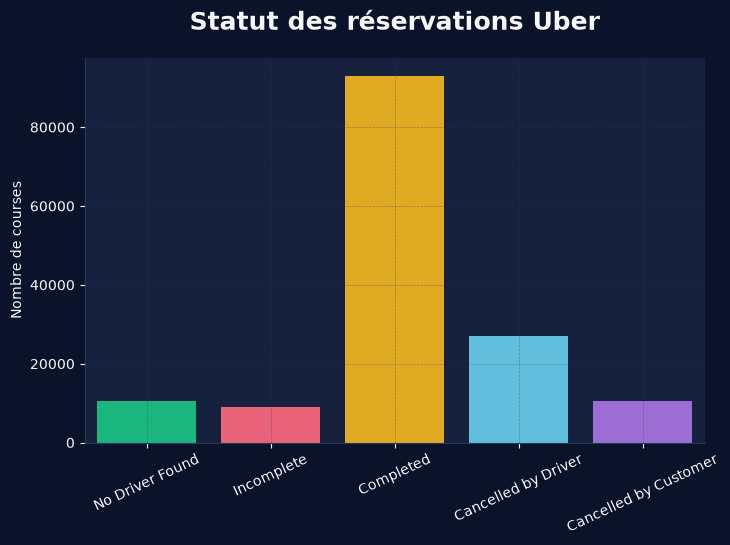

In [4]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Booking Status",
    hue="Booking Status",
    palette=[
        UBER_GREEN,
        RED,
        ORANGE,
        BLUE,
        "#9B5DE5"
    ],
    legend=False
)
uber_style(
    ax,
    "Statut des réservations Uber"
)

plt.xticks(rotation=25)
plt.ylabel("Nombre de courses")
plt.xlabel("")

plt.show()

### 2. Causes d'annulation client

Analyse :

Les principales causes permettent d'identifier les problèmes d'expérience client.

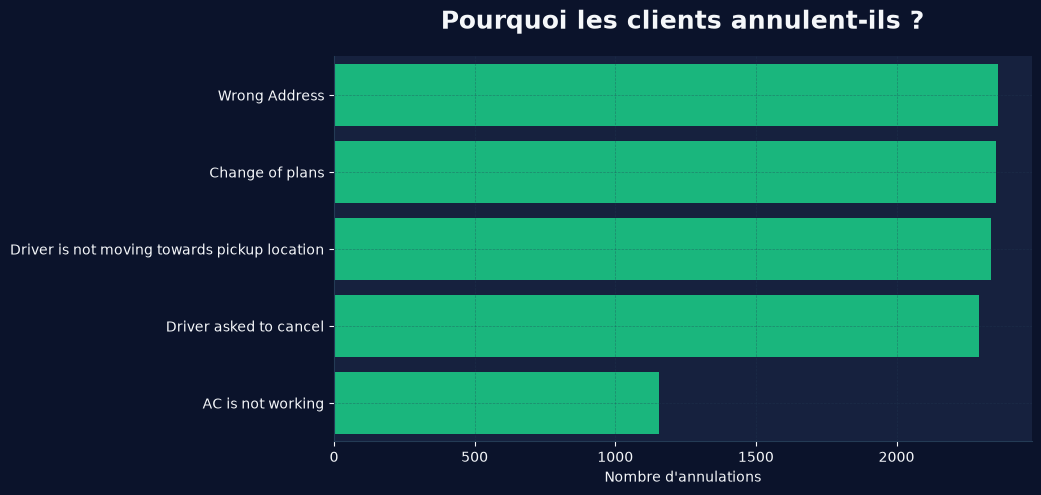

In [5]:
cancel_client = (
    df["Reason for cancelling by Customer"]
    .value_counts()
)


plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=cancel_client.values,
    y=cancel_client.index,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Pourquoi les clients annulent-ils ?"
)

plt.xlabel("Nombre d'annulations")
plt.ylabel("")

plt.show()

### 3. Annulations chauffeurs

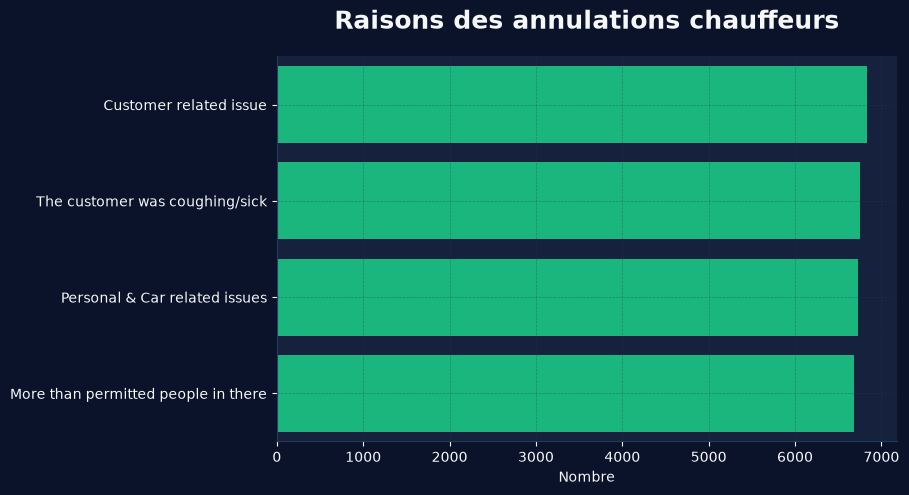

In [6]:
driver_cancel = (
    df["Driver Cancellation Reason"]
    .value_counts()
)


plt.figure(figsize=(8,5))

ax=sns.barplot(
    x=driver_cancel.values,
    y=driver_cancel.index,
    color="#00D084"
)

uber_style(
    ax,
    "Raisons des annulations chauffeurs"
)

plt.xlabel("Nombre")
plt.ylabel("")

plt.show()

### 4. Véhicules les plus utilisés
Analyse :

Permet d'identifier les véhicules les plus demandés.

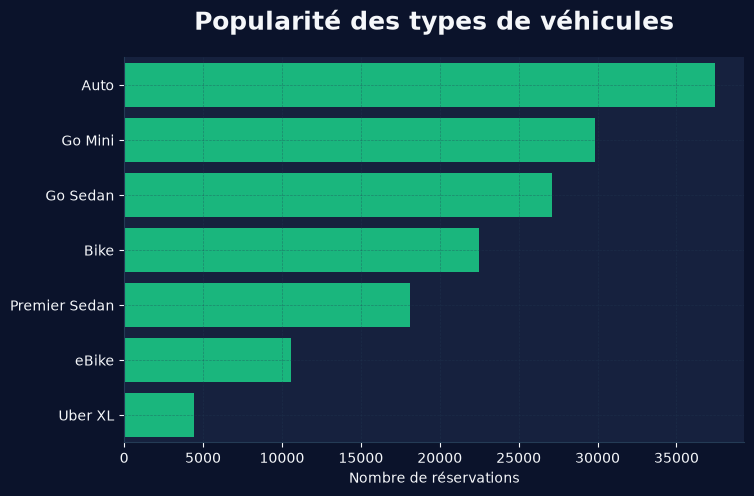

In [7]:
vehicle = df["Vehicle Type"].value_counts()


plt.figure(figsize=(8,5))

ax=sns.barplot(
    x=vehicle.values,
    y=vehicle.index,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Popularité des types de véhicules"
)

plt.xlabel("Nombre de réservations")
plt.ylabel("")

plt.show()

### 5. Revenus par type de véhicule

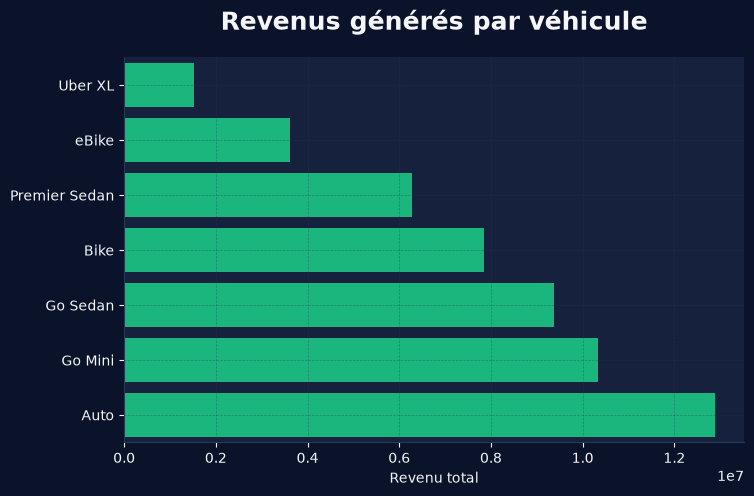

In [8]:
revenue = (
    df.groupby("Vehicle Type")["Booking Value"]
    .sum()
    .sort_values()
)


plt.figure(figsize=(8,5))

ax=sns.barplot(
    x=revenue.values,
    y=revenue.index,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Revenus générés par véhicule"
)

plt.xlabel("Revenu total")
plt.ylabel("")

plt.show()

### 6. Evolution des réservations par mois

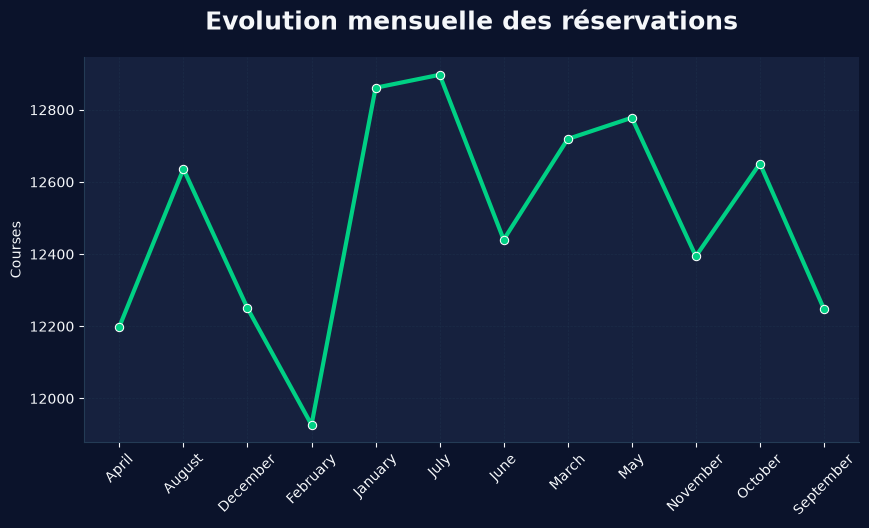

In [9]:
monthly = (
    df.groupby("Month")
    .size()
)


plt.figure(figsize=(10,5))

ax=sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    color=UBER_GREEN,
    linewidth=3
)

uber_style(
    ax,
    "Evolution mensuelle des réservations"
)

plt.xticks(rotation=45)
plt.ylabel("Courses")
plt.xlabel("")

plt.show()

### 7. Heures de pointe

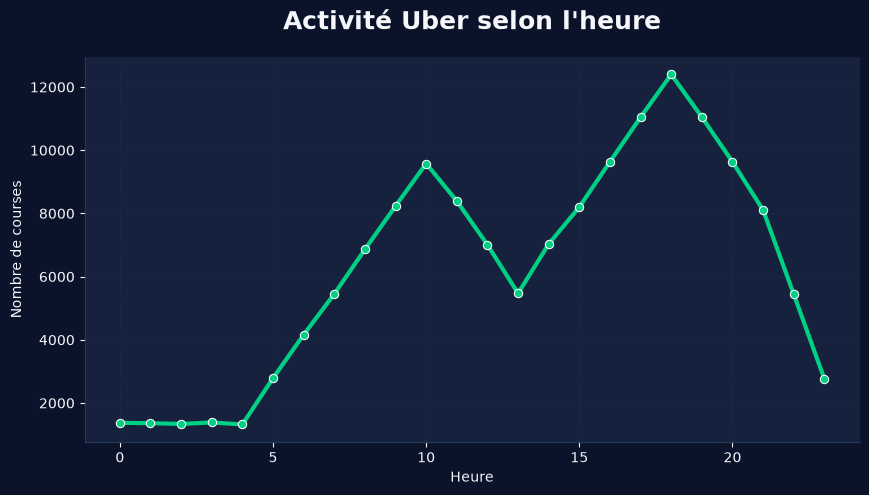

In [10]:
hourly = df["Hour"].value_counts().sort_index()


plt.figure(figsize=(10,5))

ax=sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker="o",
    color=UBER_GREEN,
    linewidth=3
)

uber_style(
    ax,
    "Activité Uber selon l'heure"
)

plt.xlabel("Heure")
plt.ylabel("Nombre de courses")

plt.show()

### 8. Relation distance / prix

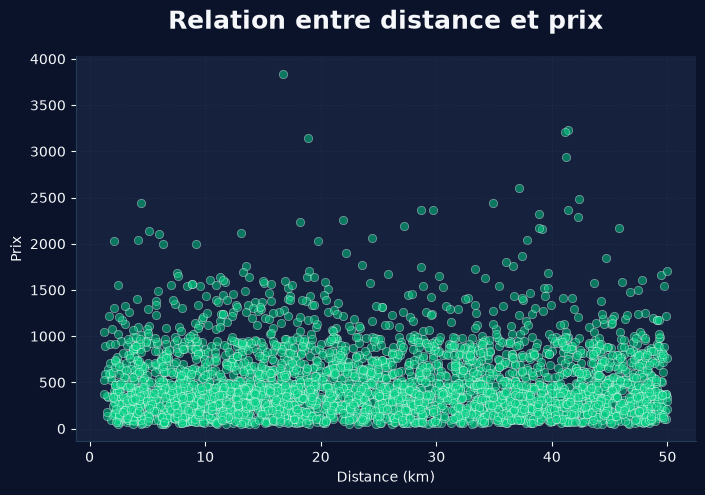

In [11]:
plt.figure(figsize=(8,5))

sample=df.sample(5000)

ax=sns.scatterplot(
    data=sample,
    x="Ride Distance",
    y="Booking Value",
    color=UBER_GREEN,
    alpha=0.5
)

uber_style(
    ax,
    "Relation entre distance et prix"
)

plt.xlabel("Distance (km)")
plt.ylabel("Prix")

plt.show()

### 9. Distribution des notes clients

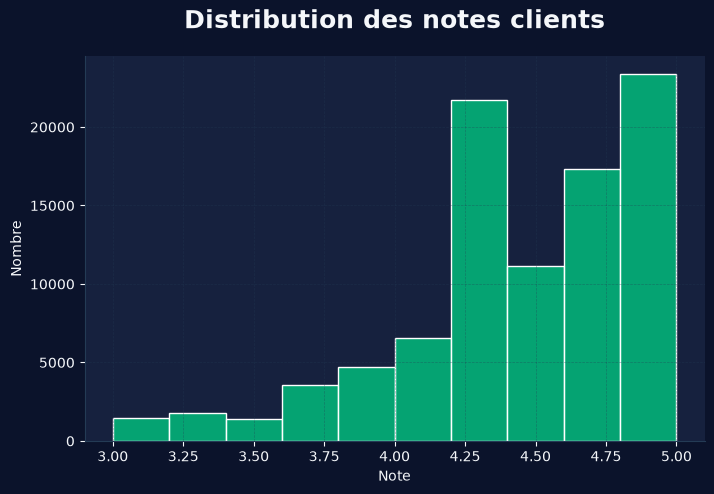

In [12]:
plt.figure(figsize=(8,5))

ax=sns.histplot(
    df["Customer Rating"],
    bins=10,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Distribution des notes clients"
)

plt.xlabel("Note")
plt.ylabel("Nombre")

plt.show()

### 10. Carte thermique des réservations

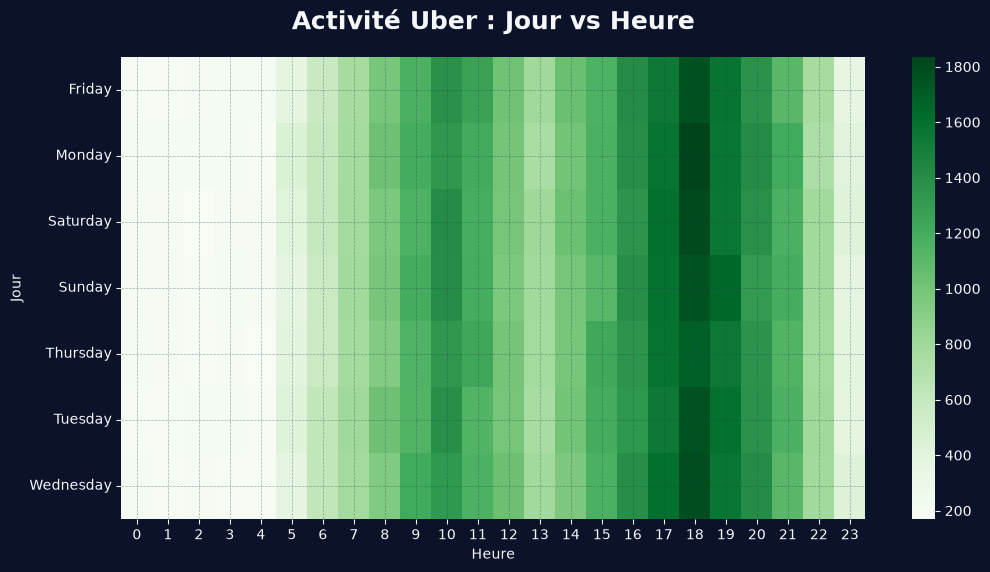

In [13]:
pivot = pd.crosstab(
    df["Day"],
    df["Hour"]
)


plt.figure(figsize=(12,6))

ax=sns.heatmap(
    pivot,
    cmap="Greens"
)

uber_style(
    ax,
    "Activité Uber : Jour vs Heure"
)

plt.xlabel("Heure")
plt.ylabel("Jour")

plt.show()

In [14]:
# Charger le fichier
df = pd.read_csv("locations_gps.csv")


# ==============================
# Classification des zones
# ==============================

rich_zones = [
    "Palam Vihar",
    "Central Secretariat",
    "AIIMS",
    "Udyog Bhawan",
    "Vidhan Sabha",
    "Patel Chowk",
    "Pitampura",
    "Punjabi Bagh",
    "Noida Sector 18",
    "Cyber Hub",
    "Qutub Minar",
    "DLF City Court",
    "Civil Lines Gurgaon",
    "Rajiv Chowk",
    "MG Road",
    "Ardee City",
    "Lajpat Nagar",
    "Sushant Lok",
    "IIT Delhi",
    "Khan Market",
    "DLF Phase 3",
    "Huda City Centre",
    "India Gate",
    "Barakhamba Road",
    "Gurgaon Sector 56",
    "Gurgaon Sector 29",
    "Jor Bagh",
    "Saket",
    "Lok Kalyan Marg",
    "Greater Kailash",
    "South Extension",
    "Green Park",
    "Chanakyapuri",
    "RK Puram",
    "Vasant Kunj",
    "Hauz Khas",
    "Panchsheel Park",
    "Golf Course Road",
    "Bhikaji Cama Place",
    "Ambience Mall"
]


poor_zones = [
    "Khandsa",
    "Madipur",
    "Jama Masjid",
    "Okhla",
    "Sadar Bazar Gurgaon",
    "Shastri Park",
    "Mundka",
    "Seelampur",
    "Dilshad Garden",
    "Aya Nagar",
    "Tughlakabad",
    "Shahdara",
    "Welcome",
    "Jahangirpuri",
    "Govindpuri",
    "Badarpur",
    "Samaypur Badli",
    "Paharganj",
    "Gurgaon Railway Station",
    "Basai Dhankot",
    "Bhiwadi"
]


# ==============================
# Fonction de classification
# ==============================

def classify_income(place):

    if place in rich_zones:
        return "Rich"

    elif place in poor_zones:
        return "Poor"

    else:
        return "Middle"


# Ajouter la colonne
df["Income_Level"] = df["Place"].apply(classify_income)


# Sauvegarder
df.to_csv(
    "locations_gps_income.csv",
    index=False,
    encoding="utf-8"
)


print("Fichier créé : locations_gps_income.csv")
print(df["Income_Level"].value_counts())


Fichier créé : locations_gps_income.csv
Income_Level
Middle    115
Rich       40
Poor       21
Name: count, dtype: int64


In [15]:
import pandas as pd

# Charger les fichiers
rides = pd.read_csv("ncr_ride_bookings_clean.csv")
locations = pd.read_csv("locations_gps_income.csv")


# Vérifier les noms des colonnes
print(rides.columns)
print(locations.columns)


# Fusionner avec les catégories socio-économiques
rides = rides.merge(
    locations[["Place", "Income_Level"]],
    left_on="Pickup Location",
    right_on="Place",
    how="left"
)


# Supprimer la colonne Place créée par le merge (optionnel)
rides.drop(
    columns=["Place"],
    inplace=True
)


# Sauvegarder le nouveau dataset complet
rides.to_csv(
    "ncr_ride_bookings_with_income.csv",
    index=False,
    encoding="utf-8"
)


print("Dataset créé :", rides.shape)
print(rides.head())


Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')
Index(['Place', 'Latitude', 'Longitude', 'Income_Level'], dtype='str')
Dataset créé : (150000, 22)
         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"  

In [16]:
cancel_rate = (
    rides.groupby("Income_Level")["Booking Status"]
    .apply(lambda x: (x=="Cancelled by Customer").mean()*100)
)

print(cancel_rate)


Income_Level
Middle    7.123069
Poor      6.956860
Rich      6.670374
Name: Booking Status, dtype: float64


Cancelled
False    112500
True      37500
Name: count, dtype: int64


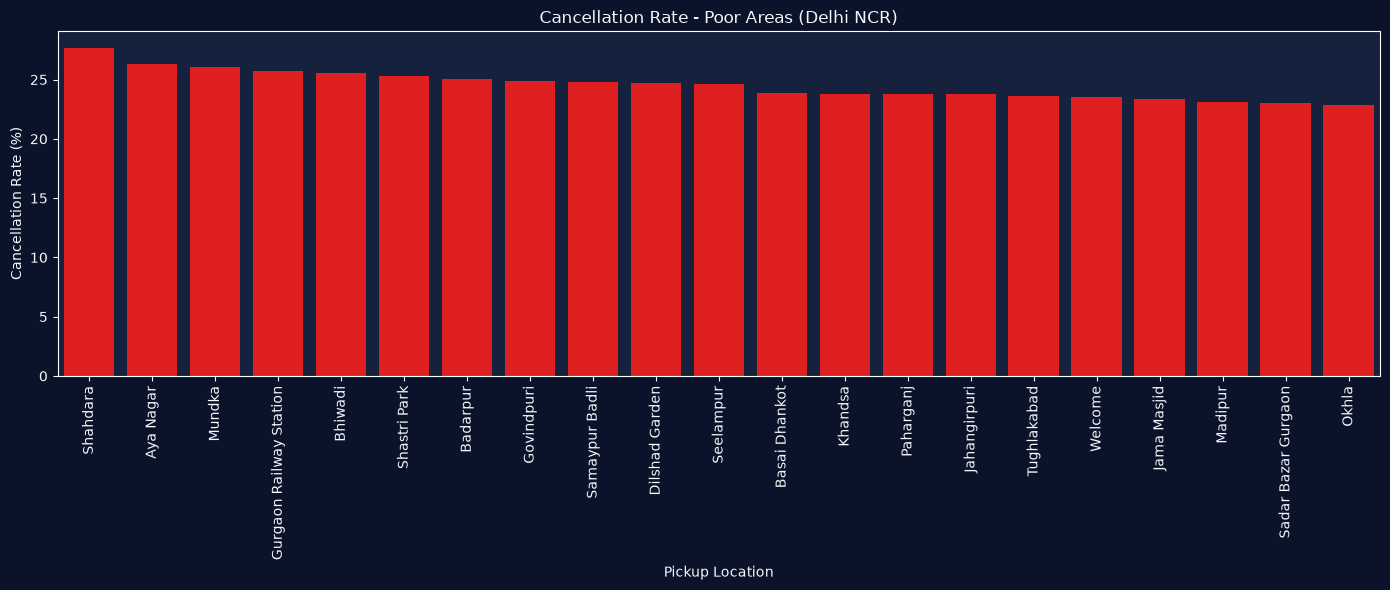

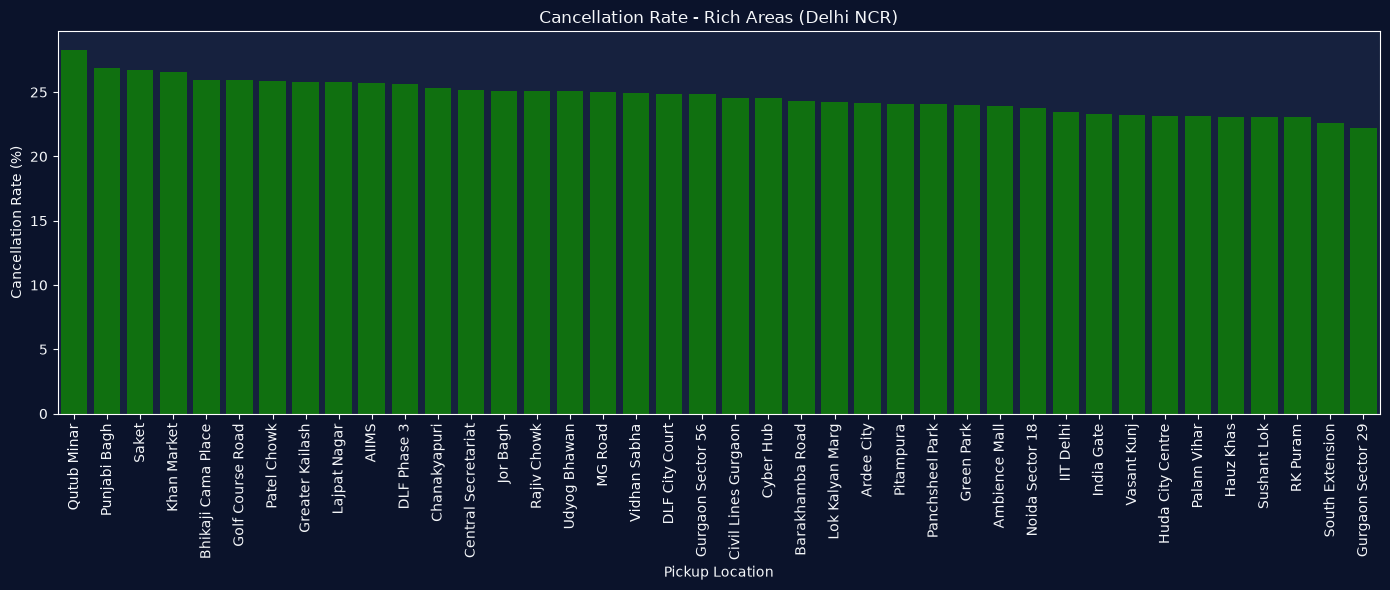

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Charger le dataset
df = pd.read_csv("ncr_ride_bookings_with_income.csv")


# ==============================
# Créer la variable Annulation
# uniquement client + chauffeur
# ==============================

df["Cancelled"] = (
    df["Cancelled Rides by Customer"].notna()
    |
    df["Cancelled Rides by Driver"].notna()
)


# Vérification
print(df["Cancelled"].value_counts())


# ==============================
# Taux d'annulation par zone
# ==============================

cancel_rate = (
    df.groupby(["Income_Level", "Pickup Location"])
    ["Cancelled"]
    .mean()
    .reset_index()
)

cancel_rate["Cancellation Rate (%)"] = (
    cancel_rate["Cancelled"] * 100
)


# ==============================
# Graphique zones pauvres
# ==============================

poor = (
    cancel_rate[cancel_rate["Income_Level"] == "Poor"]
    .sort_values(
        "Cancellation Rate (%)",
        ascending=False
    )
)


plt.figure(figsize=(14,6))

sns.barplot(
    data=poor,
    x="Pickup Location",
    y="Cancellation Rate (%)",
    color="red"
)

plt.xticks(rotation=90)

plt.title(
    "Cancellation Rate - Poor Areas (Delhi NCR)"
)

plt.xlabel("Pickup Location")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.show()



# ==============================
# Graphique zones riches
# ==============================

rich = (
    cancel_rate[cancel_rate["Income_Level"] == "Rich"]
    .sort_values(
        "Cancellation Rate (%)",
        ascending=False
    )
)


plt.figure(figsize=(14,6))

sns.barplot(
    data=rich,
    x="Pickup Location",
    y="Cancellation Rate (%)",
    color="green"
)

plt.xticks(rotation=90)

plt.title(
    "Cancellation Rate - Rich Areas (Delhi NCR)"
)

plt.xlabel("Pickup Location")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_10696\1683665238.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


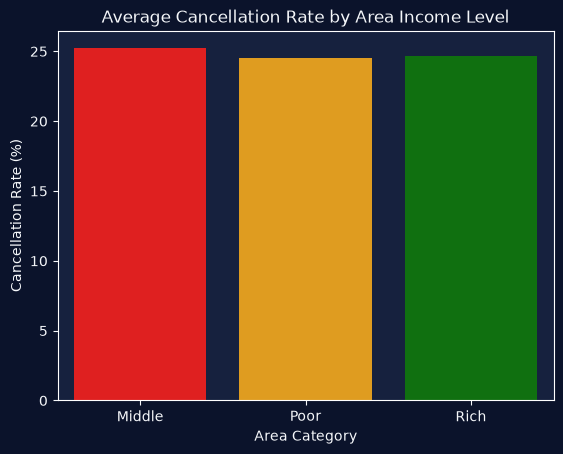

In [18]:
avg_income = (
    df.groupby("Income_Level")["Cancelled"]
    .mean()
    .reset_index()
)

avg_income["Cancellation Rate (%)"] = (
    avg_income["Cancelled"] * 100
)

sns.barplot(
    data=avg_income,
    x="Income_Level",
    y="Cancellation Rate (%)",
    palette=["red","orange","green"]
)

plt.title("Average Cancellation Rate by Area Income Level")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Area Category")
plt.show()


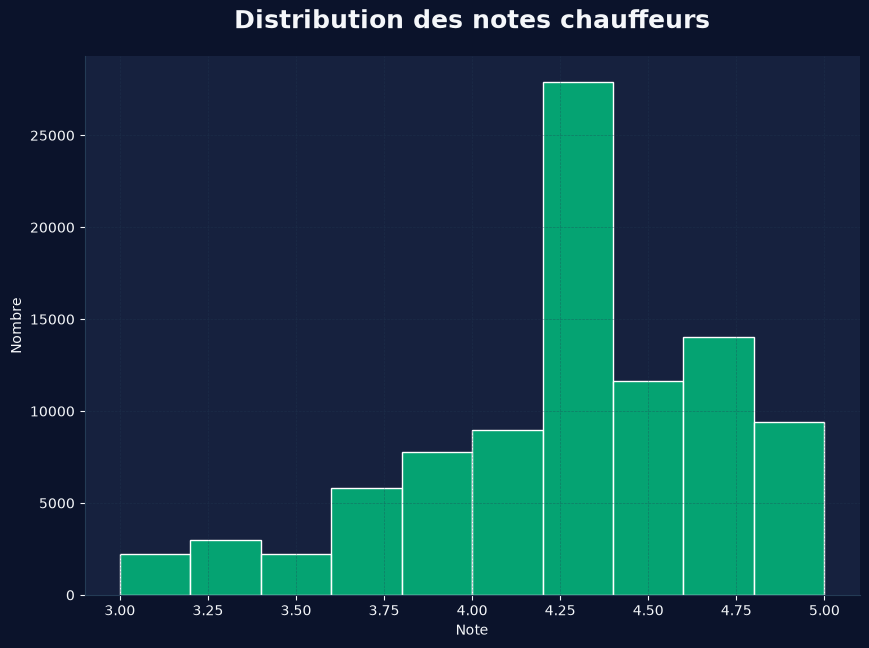

In [19]:
plt.figure(figsize=(10,7))

ax=sns.histplot(
    df["Driver Ratings"],
    bins=10,
    color=UBER_GREEN
)

uber_style(
    ax,
    "Distribution des notes chauffeurs"
)

plt.xlabel("Note")
plt.ylabel("Nombre")

plt.show()

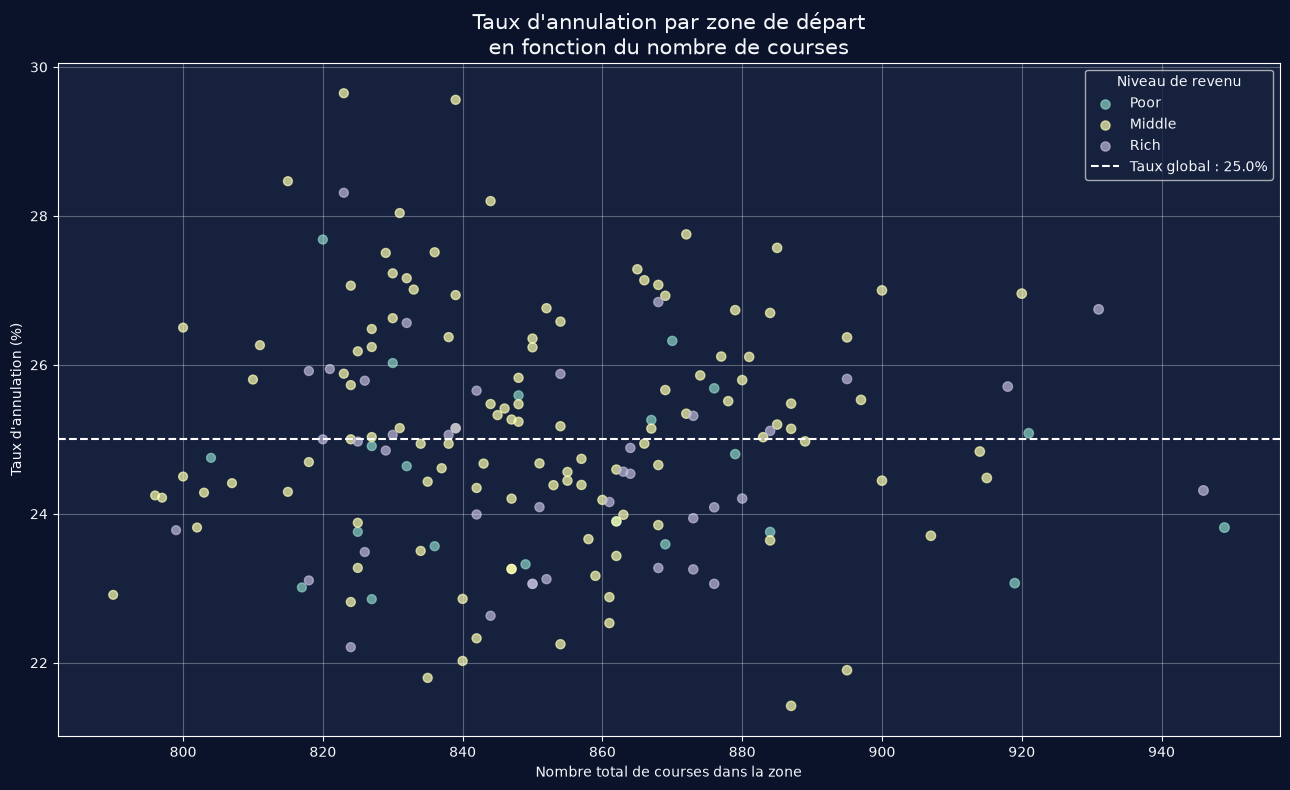

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. CHARGEMENT
# ============================================================

rides = pd.read_csv("ncr_ride_bookings_clean.csv")
income = pd.read_csv("locations_gps_income.csv")


# ============================================================
# 2. NETTOYAGE DES NOMS
# ============================================================

rides["Pickup Location"] = (
    rides["Pickup Location"]
    .astype(str)
    .str.strip()
)

income["Place"] = (
    income["Place"]
    .astype(str)
    .str.strip()
)

income["Income_Level"] = (
    income["Income_Level"]
    .astype(str)
    .str.strip()
    .str.title()
)


# ============================================================
# 3. TABLE DE CORRESPONDANCE
# ============================================================

income_mapping = (
    income[["Place", "Income_Level"]]
    .drop_duplicates(subset="Place")
)


# ============================================================
# 4. JOINTURE
# ============================================================

rides = rides.merge(
    income_mapping,
    left_on="Pickup Location",
    right_on="Place",
    how="left"
)


# ============================================================
# 5. VARIABLE ANNULATION
# ============================================================

rides["Is_Cancelled"] = (
    rides["Booking Status"]
    .astype(str)
    .str.lower()
    .str.contains("cancel")
)


# ============================================================
# 6. CALCUL PAR ZONE
# ============================================================

zone_analysis = (
    rides
    .dropna(subset=["Income_Level"])
    .groupby(["Pickup Location", "Income_Level"])
    .agg(
        Nombre_Courses=("Is_Cancelled", "size"),
        Nombre_Annulees=("Is_Cancelled", "sum")
    )
    .reset_index()
)

zone_analysis["Taux_Annulation"] = (
    zone_analysis["Nombre_Annulees"]
    / zone_analysis["Nombre_Courses"]
    * 100
)


# ============================================================
# 7. SCATTER PLOT
# ============================================================

plt.figure(figsize=(13, 8))

for income_level in ["Poor", "Middle", "Rich"]:

    data = zone_analysis[
        zone_analysis["Income_Level"] == income_level
    ]

    plt.scatter(
        data["Nombre_Courses"],
        data["Taux_Annulation"],
        s=data["Nombre_Courses"] / 20,
        alpha=0.7,
        label=income_level
    )


# Ligne du taux global
global_cancel_rate = rides["Is_Cancelled"].mean() * 100

plt.axhline(
    global_cancel_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Taux global : {global_cancel_rate:.1f}%"
)


plt.title(
    "Taux d'annulation par zone de départ\n"
    "en fonction du nombre de courses",
    fontsize=15
)

plt.xlabel("Nombre total de courses dans la zone")
plt.ylabel("Taux d'annulation (%)")

plt.grid(alpha=0.3)
plt.legend(title="Niveau de revenu")

plt.tight_layout()
plt.show()

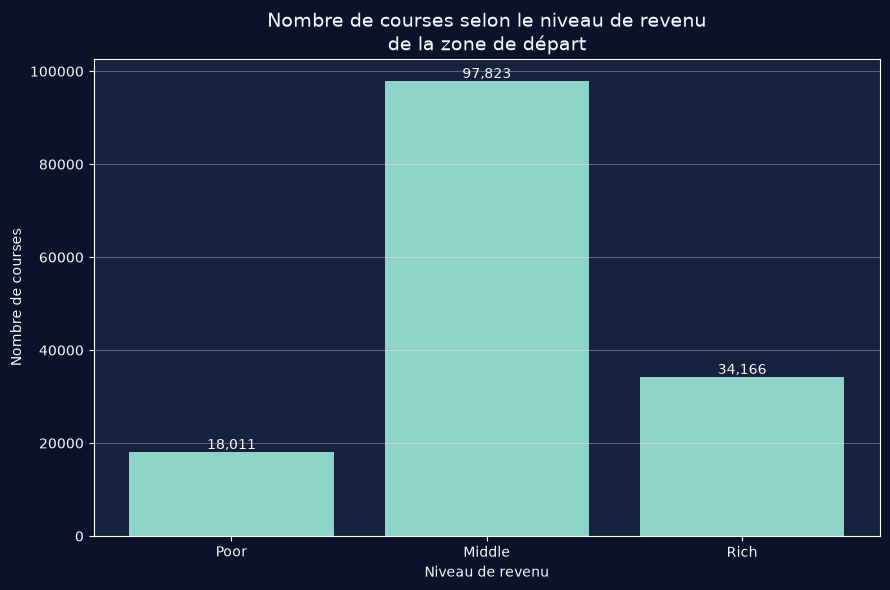

In [22]:
# ============================================================
# 9. NOMBRE DE COURSES PAR NIVEAU DE REVENU
# ============================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    analysis.index,
    analysis["Total_Courses"]
)

plt.title(
    "Nombre de courses selon le niveau de revenu\n"
    "de la zone de départ",
    fontsize=14
)

plt.xlabel("Niveau de revenu")
plt.ylabel("Nombre de courses")

for bar, value in zip(bars, analysis["Total_Courses"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

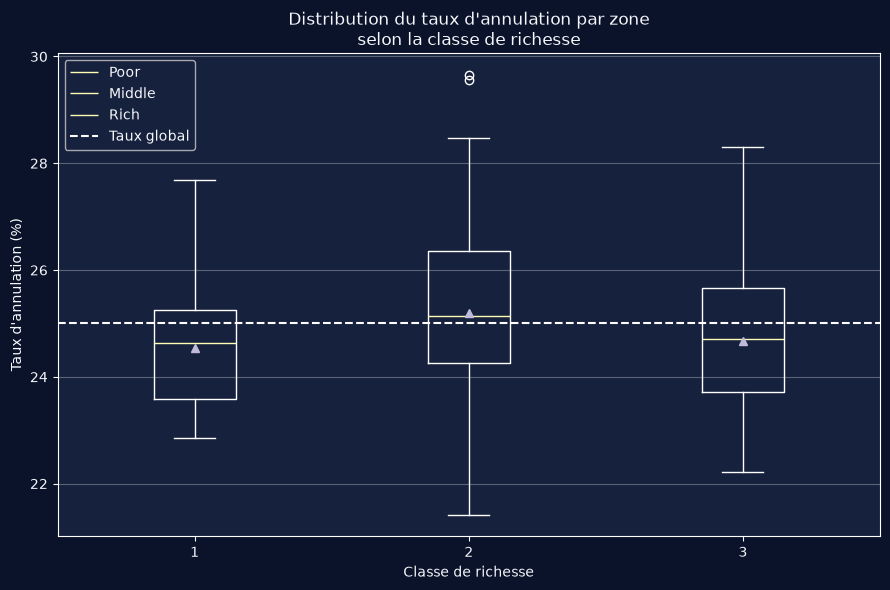

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Taux d'annulation par zone
zone_analysis = (
    rides
    .dropna(subset=["Income_Level"])
    .groupby(["Pickup Location", "Income_Level"])
    .agg(
        Total_Courses=("Is_Cancelled", "size"),
        Cancelled=("Is_Cancelled", "sum")
    )
    .reset_index()
)

zone_analysis["Cancellation_Rate"] = (
    zone_analysis["Cancelled"]
    / zone_analysis["Total_Courses"]
    * 100
)

# Boxplot
data = [
    zone_analysis.loc[
        zone_analysis["Income_Level"] == level,
        "Cancellation_Rate"
    ]
    for level in ["Poor", "Middle", "Rich"]
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    data,
    label=["Poor", "Middle", "Rich"],
    showmeans=True
)

plt.axhline(
    rides["Is_Cancelled"].mean() * 100,
    linestyle="--",
    linewidth=1.5,
    label="Taux global"
)

plt.ylabel("Taux d'annulation (%)")
plt.xlabel("Classe de richesse")
plt.title(
    "Distribution du taux d'annulation par zone\n"
    "selon la classe de richesse"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

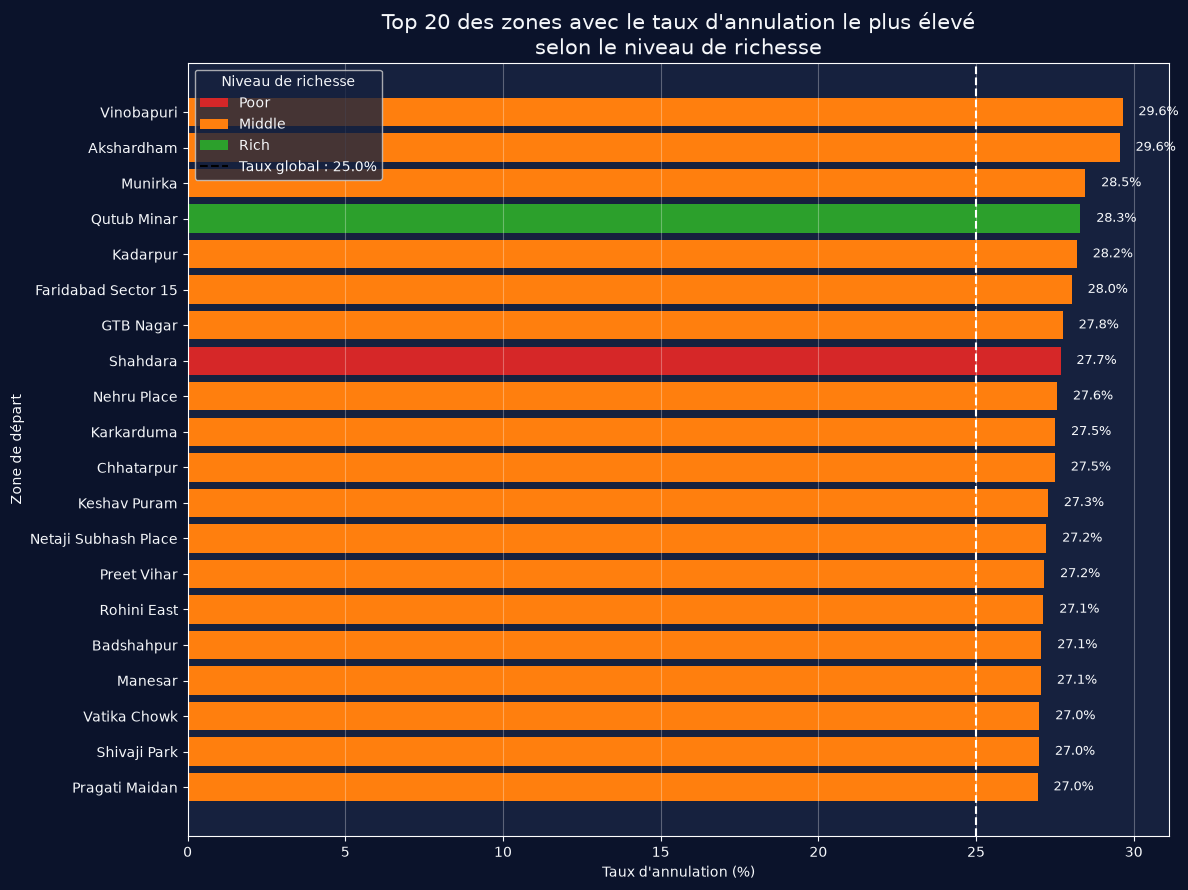


TOP 20 DES ZONES
     Pickup Location Income_Level  Nombre_Courses  Nombre_Annulees  Taux_Annulation
      Pragati Maidan       Middle             920              248            26.96
        Shivaji Park       Middle             900              243            27.00
        Vatika Chowk       Middle             833              225            27.01
             Manesar       Middle             824              223            27.06
          Badshahpur       Middle             868              235            27.07
         Rohini East       Middle             866              235            27.14
         Preet Vihar       Middle             832              226            27.16
Netaji Subhash Place       Middle             830              226            27.23
        Keshav Puram       Middle             865              236            27.28
          Chhatarpur       Middle             829              228            27.50
          Karkarduma       Middle             836         

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. CHARGEMENT DES FICHIERS
# ============================================================

rides = pd.read_csv("ncr_ride_bookings_clean.csv")
income = pd.read_csv("locations_gps_income.csv")


# ============================================================
# 2. NETTOYAGE
# ============================================================

rides["Pickup Location"] = (
    rides["Pickup Location"]
    .astype(str)
    .str.strip()
)

income["Place"] = (
    income["Place"]
    .astype(str)
    .str.strip()
)

income["Income_Level"] = (
    income["Income_Level"]
    .astype(str)
    .str.strip()
    .str.title()
)


# ============================================================
# 3. CRÉER LA VARIABLE ANNULATION
# ============================================================

rides["Is_Cancelled"] = (
    rides["Booking Status"]
    .astype(str)
    .str.lower()
    .str.contains("cancel")
)


# ============================================================
# 4. CALCUL DU TAUX D'ANNULATION PAR ZONE
# ============================================================

zone_analysis = (
    rides
    .groupby("Pickup Location")
    .agg(
        Nombre_Courses=("Is_Cancelled", "size"),
        Nombre_Annulees=("Is_Cancelled", "sum")
    )
    .reset_index()
)

zone_analysis["Taux_Annulation"] = (
    zone_analysis["Nombre_Annulees"]
    / zone_analysis["Nombre_Courses"]
    * 100
)


# ============================================================
# 5. AJOUT DU NIVEAU DE RICHESSE
# ============================================================

income_mapping = (
    income[["Place", "Income_Level"]]
    .drop_duplicates("Place")
)

zone_analysis = zone_analysis.merge(
    income_mapping,
    left_on="Pickup Location",
    right_on="Place",
    how="left"
)


# ============================================================
# 6. FILTRER LES ZONES AVEC AU MOINS 100 COURSES
# ============================================================

MIN_COURSES = 100

zone_analysis = zone_analysis[
    zone_analysis["Nombre_Courses"] >= MIN_COURSES
].copy()


# ============================================================
# 7. TAUX GLOBAL
# ============================================================

global_rate = rides["Is_Cancelled"].mean() * 100


# ============================================================
# 8. TOP 20
# ============================================================

top20 = (
    zone_analysis
    .sort_values(
        "Taux_Annulation",
        ascending=False
    )
    .head(20)
    .sort_values(
        "Taux_Annulation",
        ascending=True
    )
)


# ============================================================
# 9. ATTRIBUTION DES COULEURS
# ============================================================

colors = {
    "Poor": "tab:red",
    "Middle": "tab:orange",
    "Rich": "tab:green"
}

bar_colors = [
    colors.get(level, "gray")
    for level in top20["Income_Level"]
]


# ============================================================
# 10. GRAPHIQUE
# ============================================================

plt.figure(figsize=(12, 9))

bars = plt.barh(
    top20["Pickup Location"],
    top20["Taux_Annulation"],
    color=bar_colors
)


# ============================================================
# 11. VALEURS SUR LES BARRES
# ============================================================

for bar, rate in zip(
    bars,
    top20["Taux_Annulation"]
):

    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%",
        va="center",
        fontsize=9
    )


# ============================================================
# 12. LIGNE DU TAUX GLOBAL
# ============================================================

plt.axvline(
    global_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Taux global : {global_rate:.1f}%"
)


# ============================================================
# 13. LÉGENDE DES CLASSES
# ============================================================

from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor="tab:red",
        label="Poor"
    ),
    Patch(
        facecolor="tab:orange",
        label="Middle"
    ),
    Patch(
        facecolor="tab:green",
        label="Rich"
    )
]

legend_elements.append(
    plt.Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        label=f"Taux global : {global_rate:.1f}%"
    )
)


# ============================================================
# 14. TITRE ET AXES
# ============================================================

plt.title(
    "Top 20 des zones avec le taux d'annulation le plus élevé\n"
    "selon le niveau de richesse",
    fontsize=15
)

plt.xlabel("Taux d'annulation (%)")
plt.ylabel("Zone de départ")

plt.legend(
    handles=legend_elements,
    title="Niveau de richesse"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. TABLEAU DES 20 ZONES
# ============================================================

print("\nTOP 20 DES ZONES")
print("=" * 80)

print(
    top20[
        [
            "Pickup Location",
            "Income_Level",
            "Nombre_Courses",
            "Nombre_Annulees",
            "Taux_Annulation"
        ]
    ].round(2).to_string(index=False)
)